Nome do dataset e link original: Renúncia Fiscal - Imposto de Importação (II) e Imposto sobre Produtos Industrializados (IPI). Encontrado na seção de transparência aduaneira no Portal de Dados Abertos.

Órgão responsável pela publicação: Secretaria da Receita Federal do Brasil (Ministério da Fazenda).

Descrição do tema e finalidade: O dataset apresenta as importações que tiveram algum benefício fiscal (isenção, suspensão ou redução) dos impostos II e IPI. A finalidade é a transparência pública sobre o montante de arrecadação de que o governo abriu mão para fomentar indústrias, regimes de drawback, Zona Franca de Manaus, entre outros.

Número de registros e colunas: O dataset possui 109.678 registros (linhas) e 8 colunas.

Significado das variáveis importantes:

RAZÃO SOCIAL / CNPJ: Identificação da empresa beneficiária da renúncia.

REGIME TRIBUTARIO II-IPI: Categoria do benefício (Isenção, Suspensão ou Redução).

FUNDAMENTO LEGAL II-IPI: A base legal (Lei, Decreto, Portaria) que autorizou a renúncia fiscal.

RENUNCIA II (Em Reais) e RENUNCIA IPI (Em Reais): O valor financeiro exato (em Reais) que deixou de ser pago pelo importador referente ao Imposto de Importação e ao IPI, respectivamente.

Valores ausentes por coluna:
 CNPJ                              0
RAZÃO SOCIAL                      0
CLASSE CNAE ESTAB\nIMPDR EXPDR    0
REGIME TRIBUTARIO II-IPI          0
FUNDAMENTO LEGAL II-IPI           0
ANO DESEMBARAÇO                   0
RENUNCIA II (R$)                  0
RENUNCIA IPI (R$)                 0
dtype: int64

Tipos de dados:
 CNPJ                               object
RAZÃO SOCIAL                       object
CLASSE CNAE ESTAB\nIMPDR EXPDR     object
REGIME TRIBUTARIO II-IPI           object
FUNDAMENTO LEGAL II-IPI            object
ANO DESEMBARAÇO                     int64
RENUNCIA II (R$)                  float64
RENUNCIA IPI (R$)                 float64
dtype: object

Estatísticas Descritivas Básicas:
                  RENUNCIA II (R$)  RENUNCIA IPI (R$)
Contagem               109,678.000        109,678.000
Média                3,297,721.274      1,371,486.294
Desvio Padrão       39,995,359.226     16,237,370.904
Mínimo                -208,980.010              0.

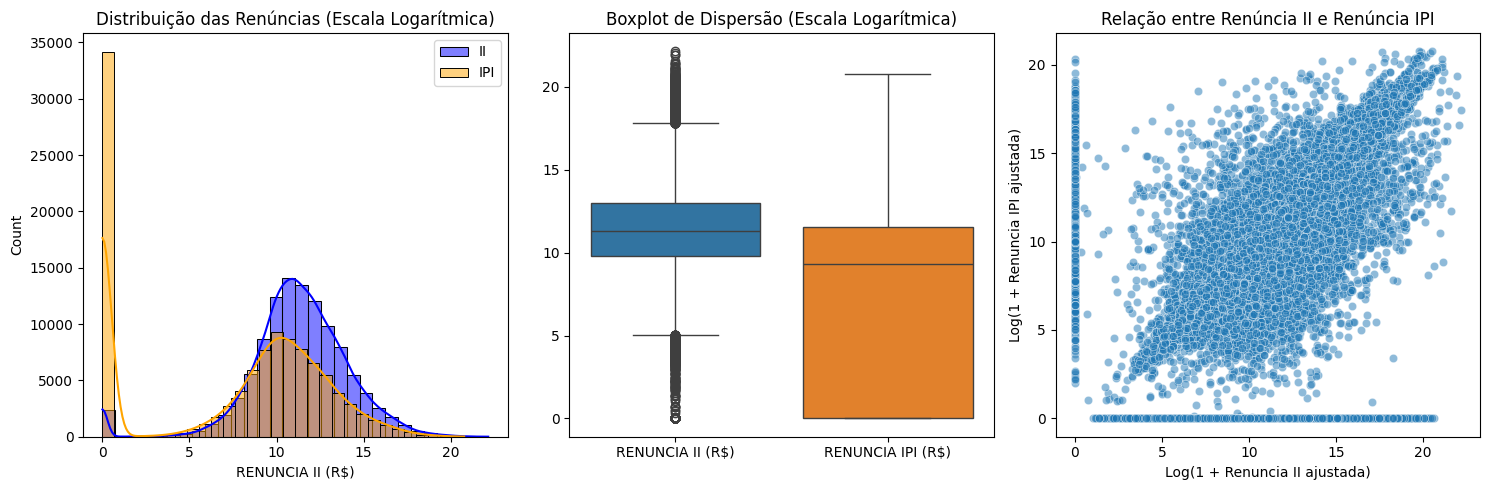

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregamento do Dataset
df = pd.read_csv('renuncia-ii-ipi.csv', sep=';', encoding='utf-8')

# 2. Limpeza dos dados
def clean_currency(x):
    if isinstance(x, str):
        x = x.replace('.', '').replace(',', '.').replace(' -   ', '0').strip()
        if x == '' or x == '-':
            return 0.0
        try:
            return float(x)
        except ValueError:
            return np.nan
    return x

df['RENUNCIA II (R$)'] = df['RENUNCIA II (R$)'].apply(clean_currency)
df['RENUNCIA IPI (R$)'] = df['RENUNCIA IPI (R$)'].apply(clean_currency)

# 3. Contagem de valores ausentes e tipos
print("Valores ausentes por coluna:\n", df.isnull().sum())
print("\nTipos de dados:\n", df.dtypes)

# 4. Estatísticas Descritivas (Com formatação aplicada)
estatisticas = df[['RENUNCIA II (R$)', 'RENUNCIA IPI (R$)']].describe()

estatisticas.index = [
    'Contagem',
    'Média',
    'Desvio Padrão',
    'Mínimo',
    '25% (1º Quartil)',
    '50% (Mediana)',
    '75% (3º Quartil)',
    'Máximo'
]

pd.options.display.float_format = '{:,.3f}'.format

print("\nEstatísticas Descritivas Básicas:")
print(estatisticas)

for col in ['RENUNCIA II (R$)', 'RENUNCIA IPI (R$)']:
    moda = df[col].mode().iloc[0]
    variancia = df[col].var()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    print(f"\n--- Estatísticas Complementares para {col} ---")
    print(f"Moda: R$ {moda:,.3f}")
    print(f"Variância: {variancia:,.3f}")
    print(f"IQR (Intervalo Interquartil): R$ {iqr:,.3f}")

# 5. Visualizações Gráficas (Aplicando Log devido à enorme diferença de escalas)
plt.figure(figsize=(15, 5))

renuncia_ii_log = np.log1p(np.clip(df['RENUNCIA II (R$)'], a_min=0, a_max=None))
renuncia_ipi_log = np.log1p(np.clip(df['RENUNCIA IPI (R$)'], a_min=0, a_max=None))

plt.subplot(1, 3, 1)
sns.histplot(renuncia_ii_log, bins=30, kde=True, color='blue', label='II')
sns.histplot(renuncia_ipi_log, bins=30, kde=True, color='orange', label='IPI')
plt.title('Distribuição das Renúncias (Escala Logarítmica)')
plt.legend()

plt.subplot(1, 3, 2)
df_log = pd.DataFrame({'RENUNCIA II (R$)': renuncia_ii_log, 'RENUNCIA IPI (R$)': renuncia_ipi_log})
sns.boxplot(data=df_log)
plt.title('Boxplot de Dispersão (Escala Logarítmica)')

# Gráfico de Dispersão (Scatter)
plt.subplot(1, 3, 3)
sns.scatterplot(x=renuncia_ii_log, y=renuncia_ipi_log, alpha=0.5)
plt.title('Relação entre Renúncia II e Renúncia IPI')
plt.xlabel('Log(1 + Renuncia II ajustada)')
plt.ylabel('Log(1 + Renuncia IPI ajustada)')

plt.tight_layout()
plt.show()

Com base na execução dessas estatísticas nos seus dados, observei os seguintes padrões e irregularidades:

Assimetria Extrema (Outliers): O dado é altamente distorcido.

Para a RENUNCIA II (Em Reais), a média é de R$ 3.297.721, porém a mediana é de apenas 81.166 Reais.

A discrepância ocorre porque o valor máximo chega a impressionantes R$ 4,19 Bilhões para uma única linha. Isso prova que a imensa maioria das empresas recebe renúncias de valor "baixo", mas um pequeno grupo de megacorporações recebe bilhões em benefícios.

Moda Concentrada em Zero: O valor que mais se repete (Moda) é R$ 0,00 para ambos os impostos. Isso ocorre porque muitos regimes de tributação dão benefício para um imposto (ex: zera o II), mas não afetam o outro (o IPI pode não ter incidido sobre aquele produto ou não possui benefício).

Irregularidade nos Dados: Ao verificar o Mínimo da coluna RENUNCIA II (Em Reais), existe um valor de -R$ 208.980,00 (negativo). Em regra, o valor de um benefício fiscal concedido não deveria ser menor que zero. Essa irregularidade sugere que pode ter havido algum ajuste contábil, devolução, autuação fiscal ou um erro de digitação/sistema por parte da Receita Federal que precisaria de tratamento futuro.

Alta Variância e Desvio Padrão: A presença de variâncias na casa dos quatrilhões e desvios padrões superiores à média comprovam que não há "padronização" nos valores; eles dependem exclusivamente do volume financeiro que cada CNPJ importa.